In [1]:
import math

class Value:
    def __init__(self,data,_children=(),_op='',label=""):
        self.data = data
        self.grad = 0.0
        self._prev = _children
        self._op = _op
        self.label = label
        self._backward = lambda:None

    def __add__(self, other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data + other.data, (self,other),"+")

        def _backward():
            self.grad += out.grad
            other.grad += out.grad

        out._backward = _backward

        return out 
    
    def __radd__(self, other):
        return self + other
    
    def __mul__(self, other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data * other.data,(self,other),"*")

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward
        return out
    
    def __rmul__(self, other):
        return self * other

    def __repr__(self):
        return f"Value: {self.data}"
    
    def __iter__(self):
        for child in self._prev:
            yield child
    
    def tanh(self):
        x = self.data
        t = math.tanh(x)
        out = Value(t,(self,),"tanh")

        def _backward():
            self.grad = (1-t**2) * out.grad

        out._backward = _backward
        return out
        



In [2]:
v1 = Value(2);v1.label = 'v1'
v2 = Value(3);v2.label = 'v2'
v3 = v1+v2;v3.label = 'v3'
b = Value(4) ;b.label = 'b'
v4 = v3+b ; v4.label = 'v4'
v5 = v4.tanh()
v5; v5.label = "v5"

In [3]:
def trace(root):
    nodes,edges = set(),set()
    def build(v):
        if not v in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child,v))
                build(child)
    build(root)
    
    return nodes,edges

from graphviz import Digraph

def draw_dots(root):
    dot = Digraph(name="graph",format='svg',graph_attr={"rankdir":"LR"})

    nodes,edges = trace(root)

    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid,label='%s | %.4f data | %.4f grad' % (n.label,n.data,n.grad),shape='record',)

        if n._op:
            dot.node(name=uid+n._op,label=n._op)
            dot.edge(uid+n._op,uid)

    for e1,e2 in edges:
        dot.edge(str(id(e1)),str(id(e2)) + e2._op)

    return dot
    

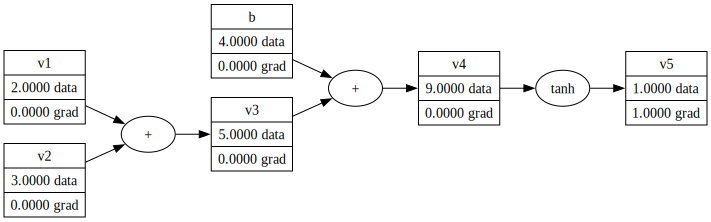

In [ ]:
# 1. Reset everything
# 2. Run the operation to create v5
v5.grad = 1.0
v5._backward()

# 3. Check v4's grad immediately
print(f"v4 grad: {v4.grad}")
draw_dots(v5)

v4 grad: 6.091991711087985e-08


In [6]:
a  = Value(2.0,label='a')
b = Value(-3.0) ; b.label = 'b'
c = Value(10) ; c.label = "c"
e = a*b; e.label = "e"
d  = e + c ;d.label = "d"
f = Value(-2.0,label="f")
l = d * f ; l.label = "L"
l

Value: -8.0

In [7]:
l.grad = 1.00
f.grad = 4.0
d.grad = -2.0
c.grad = -2.0
e.grad = -2.0
a.grad = -2.0 * -3.0
b.grad = -2.0 * 2.0

In [8]:
a.grad

6.0

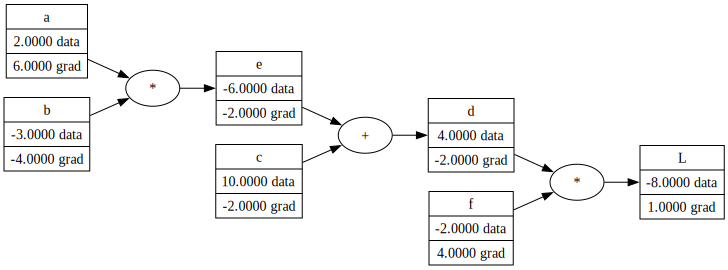

In [9]:
draw_dots(l)